# Open-FDD Engine Tutorial (RTU11)

This notebook is a beginner-friendly, **engine-only** tutorial using real data from `examples/data/RTU11.csv`.

You will learn the same flow used in the AHU7 notebook:

1. Load real timeseries data
2. Pick a few sensor columns
3. Inject synthetic faults (bounds + flatline) for learning
4. Run simple FDD logic
5. Build clean plots and hourly/monthly analytics

> Goal: make it easy to understand how flags are generated and how to summarize fault behavior.

CSV: /home/ben/open-fdd/examples/data/RTU11.csv
Rows: 1586
Using sensors: RTU_11_DA_T(°F) (main), RTU_11_MA_T(°F) (aux)
Bounds: 49.97 to 78.7
bounds_flag count: 126
flatline_flag count: 169


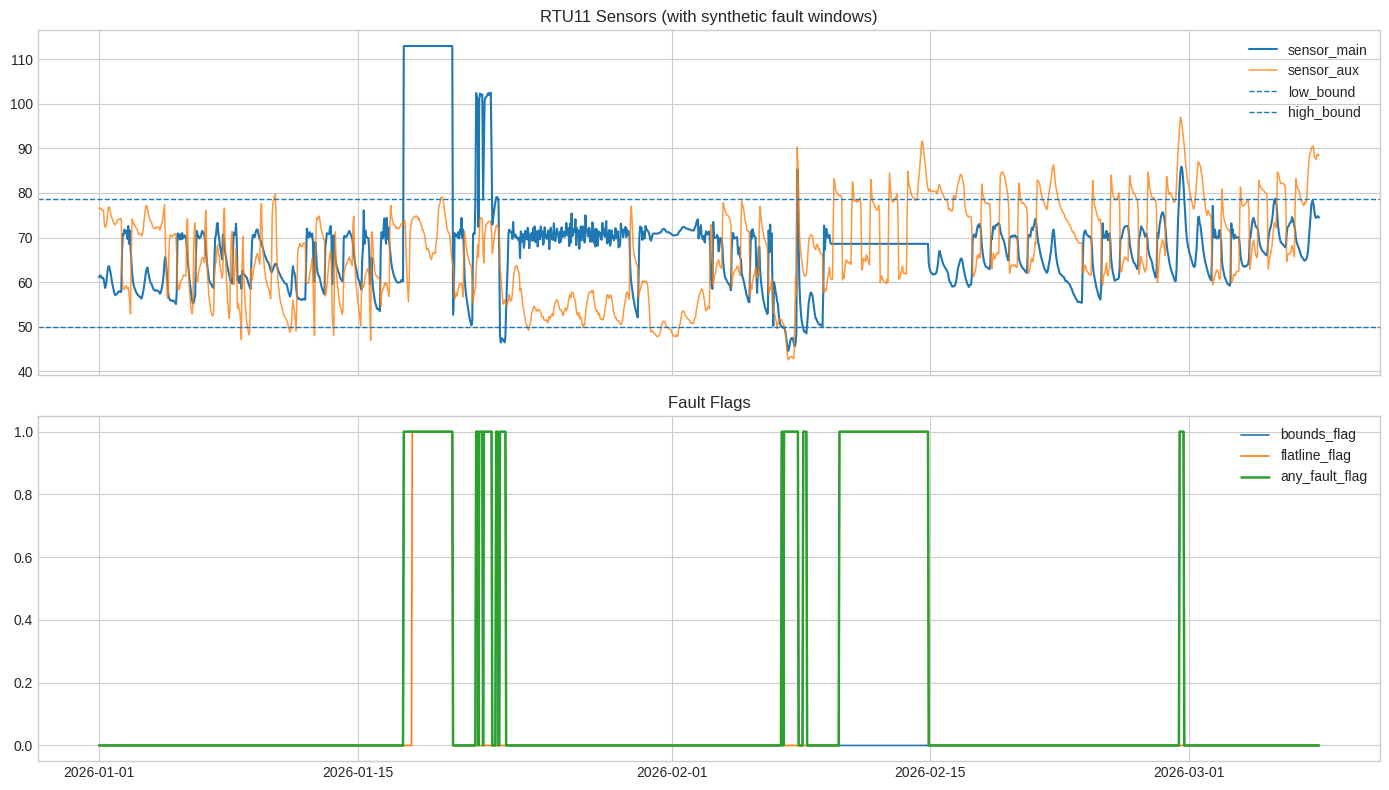

Hourly tail:


,bounds_flag_sum,bounds_flag_count,flatline_flag_sum,flatline_flag_count,any_fault_flag_sum,any_fault_flag_count,bounds_flag_rate,flatline_flag_rate,any_fault_flag_rate
hour,,,,,,,,,
2026-03-07 18:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-07 19:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-07 20:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-07 21:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-07 22:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-07 23:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-08 00:00:00,0,1,0,1,0,1,0.0,0.0,0.0
2026-03-08 01:00:00,0,1,0,1,0,1,0.0,0.0,0.0


Monthly:


,bounds_flag_sum,bounds_flag_count,flatline_flag_sum,flatline_flag_count,any_fault_flag_sum,any_fault_flag_count,bounds_flag_rate,flatline_flag_rate,any_fault_flag_rate
month,,,,,,,,,
2026-01,94,744,53,744,94,744,0.126344,0.071237,0.126344
2026-02,32,672,116,672,148,672,0.047619,0.172619,0.220238
2026-03,0,170,0,170,0,170,0.000000,0.000000,0.000000


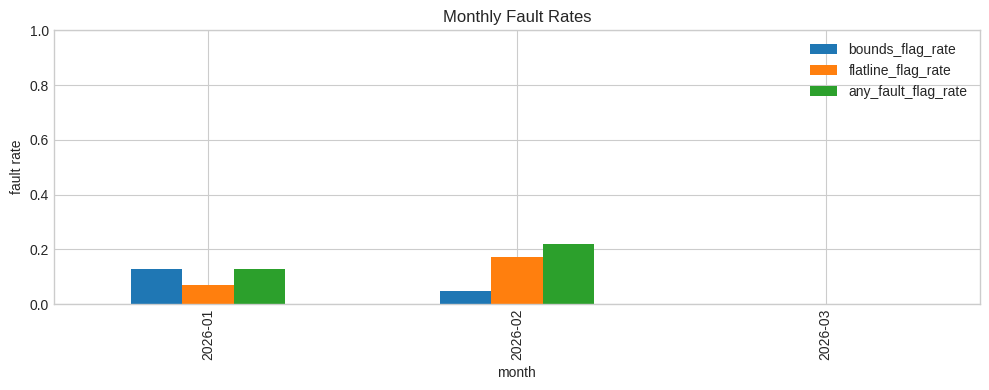

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# ---------- 1) Load data ----------
cwd = Path.cwd().resolve()
candidates = [
    cwd / "examples" / "data",            # run from repo root
    cwd / "data",                           # run from examples/
    cwd.parent / "data",                    # run from examples/RTU11
]
DATA_DIR = next((p for p in candidates if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate examples/data directory from current working dir.")

CSV_PATH = DATA_DIR / "RTU11.csv"
df_raw = pd.read_csv(CSV_PATH)

# Find a timestamp column safely
ts_candidates = [c for c in df_raw.columns if "time" in c.lower()]
if not ts_candidates:
    raise ValueError("No timestamp-like column found.")
TIMESTAMP_COL = ts_candidates[0]

# Parse timestamps (supports RTU text like "01-Jan-26 12:00:00 AM EST")
ts_text = df_raw[TIMESTAMP_COL].astype(str).str.strip()
ts_parsed = pd.to_datetime(ts_text, format="%d-%b-%y %I:%M:%S %p EST", errors="coerce")
if ts_parsed.notna().sum() == 0:
    ts_parsed = pd.to_datetime(ts_text, errors="coerce")

df_raw[TIMESTAMP_COL] = ts_parsed
df_raw = df_raw.dropna(subset=[TIMESTAMP_COL]).sort_values(TIMESTAMP_COL).reset_index(drop=True)
if len(df_raw) == 0:
    raise ValueError("No rows left after timestamp parsing. Check timestamp format in CSV.")

# Pick numeric sensors automatically (beginner friendly)
numeric_cols = [
    c for c in df_raw.columns
    if c != TIMESTAMP_COL and pd.api.types.is_numeric_dtype(df_raw[c])
]
if len(numeric_cols) < 2:
    raise ValueError("Need at least 2 numeric sensor columns in CSV.")

sensor_main = numeric_cols[0]
sensor_aux = numeric_cols[1]

df = df_raw[[TIMESTAMP_COL, sensor_main, sensor_aux]].copy()
df.columns = ["timestamp", "sensor_main", "sensor_aux"]

print(f"CSV: {CSV_PATH}")
print(f"Rows: {len(df)}")
print(f"Using sensors: {sensor_main} (main), {sensor_aux} (aux)")
df.head(3)

# ---------- 2) Inject synthetic faults for tutorial ----------
def inject_synthetic_faults(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    n = len(out)

    # Bounds fault window (spike high)
    hi_start = int(n * 0.25)
    hi_end = min(hi_start + max(10, int(n * 0.04)), n - 1)
    out.loc[hi_start:hi_end, "sensor_main"] = out["sensor_main"].median() + out["sensor_main"].std() * 6

    # Flatline fault window
    fl_start = int(n * 0.60)
    fl_end = min(fl_start + max(20, int(n * 0.08)), n - 1)
    flat_value = float(out.loc[fl_start, "sensor_main"])
    out.loc[fl_start:fl_end, "sensor_main"] = flat_value

    return out

fault_df = inject_synthetic_faults(df)

# ---------- 3) Simple FDD logic (bounds + flatline) ----------
LOW_BOUND = float(df["sensor_main"].quantile(0.02))
HIGH_BOUND = float(df["sensor_main"].quantile(0.98))

fault_df["bounds_flag"] = (
    (fault_df["sensor_main"] < LOW_BOUND) |
    (fault_df["sensor_main"] > HIGH_BOUND)
).astype(int)

window = 12
rolling_range = (
    fault_df["sensor_main"].rolling(window, min_periods=window)
    .max()
    .sub(fault_df["sensor_main"].rolling(window, min_periods=window).min())
)
fault_df["flatline_flag"] = (rolling_range < 1e-9).fillna(False).astype(int)

fault_df["any_fault_flag"] = ((fault_df["bounds_flag"] == 1) | (fault_df["flatline_flag"] == 1)).astype(int)

print("Bounds:", round(LOW_BOUND, 3), "to", round(HIGH_BOUND, 3))
print("bounds_flag count:", int(fault_df["bounds_flag"].sum()))
print("flatline_flag count:", int(fault_df["flatline_flag"].sum()))

# ---------- 4) Plot signals + flags ----------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(fault_df["timestamp"], fault_df["sensor_main"], label="sensor_main", linewidth=1.5)
axes[0].plot(fault_df["timestamp"], fault_df["sensor_aux"], label="sensor_aux", linewidth=1.1, alpha=0.8)
axes[0].axhline(LOW_BOUND, linestyle="--", linewidth=1, label="low_bound")
axes[0].axhline(HIGH_BOUND, linestyle="--", linewidth=1, label="high_bound")
axes[0].set_title("RTU11 Sensors (with synthetic fault windows)")
axes[0].legend(loc="upper right")

axes[1].plot(fault_df["timestamp"], fault_df["bounds_flag"], label="bounds_flag", linewidth=1.2)
axes[1].plot(fault_df["timestamp"], fault_df["flatline_flag"], label="flatline_flag", linewidth=1.2)
axes[1].plot(fault_df["timestamp"], fault_df["any_fault_flag"], label="any_fault_flag", linewidth=1.8)
axes[1].set_title("Fault Flags")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# ---------- 5) Beginner analytics: hourly + monthly ----------
analytics = fault_df[["timestamp", "bounds_flag", "flatline_flag", "any_fault_flag"]].copy()
analytics["hour"] = analytics["timestamp"].dt.floor("h")
analytics["month"] = analytics["timestamp"].dt.to_period("M").astype(str)

hourly = analytics.groupby("hour")[["bounds_flag", "flatline_flag", "any_fault_flag"]].agg(["sum", "count"])
hourly.columns = [f"{c}_{m}" for c, m in hourly.columns]
for f in ["bounds_flag", "flatline_flag", "any_fault_flag"]:
    hourly[f"{f}_rate"] = hourly[f"{f}_sum"] / hourly[f"{f}_count"]

monthly = analytics.groupby("month")[["bounds_flag", "flatline_flag", "any_fault_flag"]].agg(["sum", "count"])
monthly.columns = [f"{c}_{m}" for c, m in monthly.columns]
for f in ["bounds_flag", "flatline_flag", "any_fault_flag"]:
    monthly[f"{f}_rate"] = monthly[f"{f}_sum"] / monthly[f"{f}_count"]

print("Hourly tail:")
display(hourly.tail(8))
print("Monthly:")
display(monthly)

monthly[["bounds_flag_rate", "flatline_flag_rate", "any_fault_flag_rate"]].plot(
    kind="bar", figsize=(10, 4), ylim=(0, 1), title="Monthly Fault Rates"
)
plt.ylabel("fault rate")
plt.tight_layout()
plt.show()

## Optional: switch Python package profile quickly

Use these two commands in a notebook cell (or terminal) to avoid guessing which package source you are using.

### Published profile (PyPI)
```bash
!./.venv/bin/python -m pip install --upgrade open-fdd
```

### Local dev profile (this repo)
```bash
!./.venv/bin/python -m pip install -e ".[dev]"
```

### Verify active profile
```bash
!./.venv/bin/python -c "import open_fdd, importlib.metadata as m; print('version=', m.version('open-fdd')); print('path=', open_fdd.__file__)"
```

In [2]:
# Optional: run one of these when needed
# ./.venv/bin/python -m pip install --upgrade open-fdd
# ./.venv/bin/python -m pip install -e ".[dev]"
# ./.venv/bin/python -c "import open_fdd, importlib.metadata as m; print('version=', m.version('open-fdd')); print('path=', open_fdd.__file__)"